# 💬 Sentiment Analysis using Machine Learning

## Objective

The objective of this project is to build a machine learning model that classifies text into **Positive**, **Negative**, or **Neutral** sentiments. The project demonstrates Natural Language Processing (NLP) techniques including text preprocessing, feature extraction using TF-IDF, and sentiment classification using multiple machine learning algorithms.

---

In [11]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# ==========================================
# Import Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [13]:
# Download NLTK Resources

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Dataset Overview

The Twitter Entity Sentiment dataset contains tweets labelled into Positive, Negative, Neutral and Irrelevant classes. For this project, only Positive, Negative and Neutral sentiments are used.

In [14]:
# Load Dataset

df = pd.read_csv("twitter_training.csv", header=None)

df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [15]:
# Dataset Information

print(df.shape)

df.info()

(74682, 4)
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [16]:
# Missing Values

df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [17]:
# Remove Missing Values

df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

In [18]:
# Remove Irrelevant Sentiment

df = df[df["Sentiment"] != "Irrelevant"]

df["Sentiment"].value_counts()

Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

# Sentiment Distribution

Understanding the class distribution helps identify whether the dataset is balanced before model training.

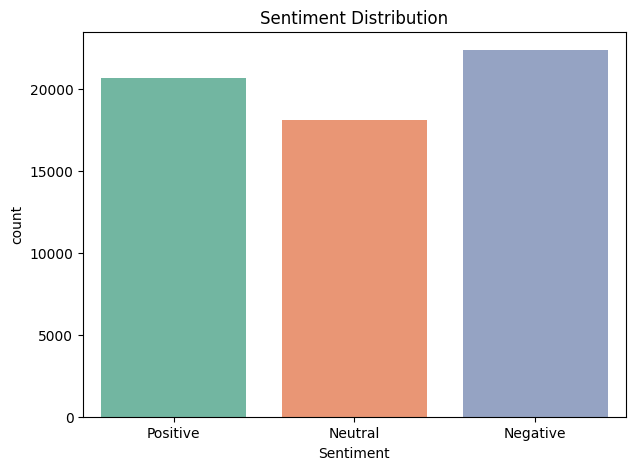

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sentiment",
    palette="Set2"
)

plt.title("Sentiment Distribution")

plt.show()

# Text Preprocessing

Text preprocessing is an essential step in Natural Language Processing (NLP). Raw text often contains punctuation, numbers, special characters, and stopwords that do not contribute to sentiment classification.

The preprocessing steps performed are:

- Convert text to lowercase
- Remove punctuation
- Remove numbers
- Remove extra spaces
- Remove stopwords
- Lemmatize words

In [20]:
# ==========================================
# Text Preprocessing Function
# ==========================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords & Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [21]:
# Apply preprocessing

df["Clean_Tweet"] = df["Tweet"].apply(preprocess_text)

df[["Tweet", "Clean_Tweet"]].head()

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


# TF-IDF Feature Extraction

Machine learning algorithms cannot directly understand text data.

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical vectors by assigning higher importance to words that are frequent in a document but less common across the entire dataset.

This representation helps improve the performance of text classification models.

In [22]:
# TF-IDF Vectorization

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["Clean_Tweet"])

y = df["Sentiment"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (61121, 5000)


# Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to build the machine learning model, while the testing data is used to evaluate its performance on unseen data.

In [23]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 48896
Testing Samples  : 12225


In [24]:
# Train Naive Bayes Model

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

print("Naive Bayes Accuracy :", accuracy_score(y_test, nb_predictions))

Naive Bayes Accuracy : 0.7162372188139059


In [25]:
# Train Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_predictions))

Logistic Regression Accuracy : 0.7571370143149284


In [26]:
print("Naive Bayes Accuracy :", accuracy_score(y_test, nb_predictions))

Naive Bayes Accuracy : 0.7162372188139059


In [27]:
print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_predictions))

Logistic Regression Accuracy : 0.7571370143149284


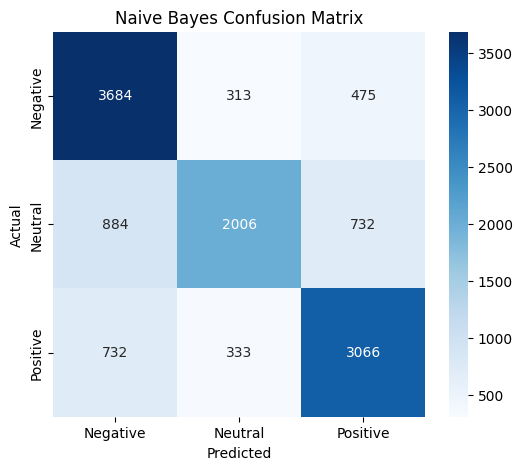

In [28]:
plt.figure(figsize=(6,5))

cm_nb = confusion_matrix(y_test, nb_predictions)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

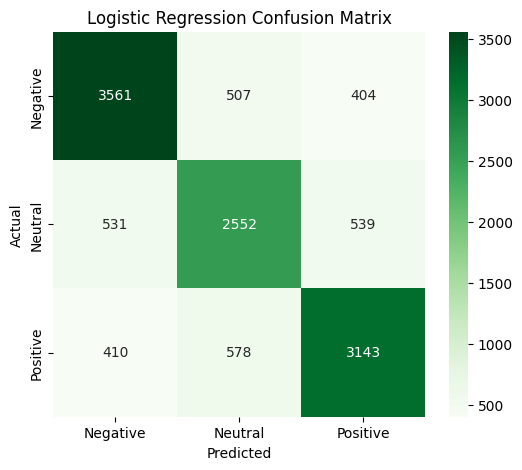

In [29]:
plt.figure(figsize=(6,5))

cm_lr = confusion_matrix(y_test, lr_predictions)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

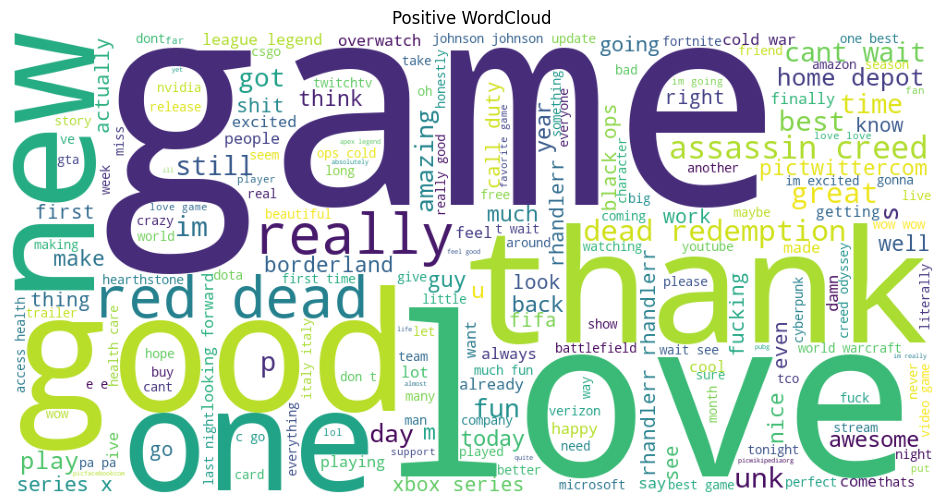

In [30]:
positive = " ".join(df[df["Sentiment"]=="Positive"]["Clean_Tweet"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive WordCloud")
plt.show()

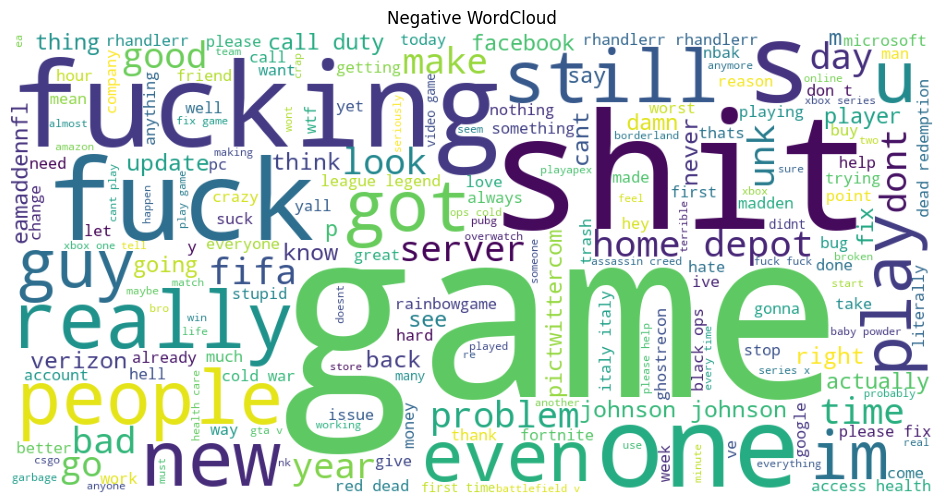

In [31]:
negative = " ".join(df[df["Sentiment"]=="Negative"]["Clean_Tweet"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative WordCloud")
plt.show()

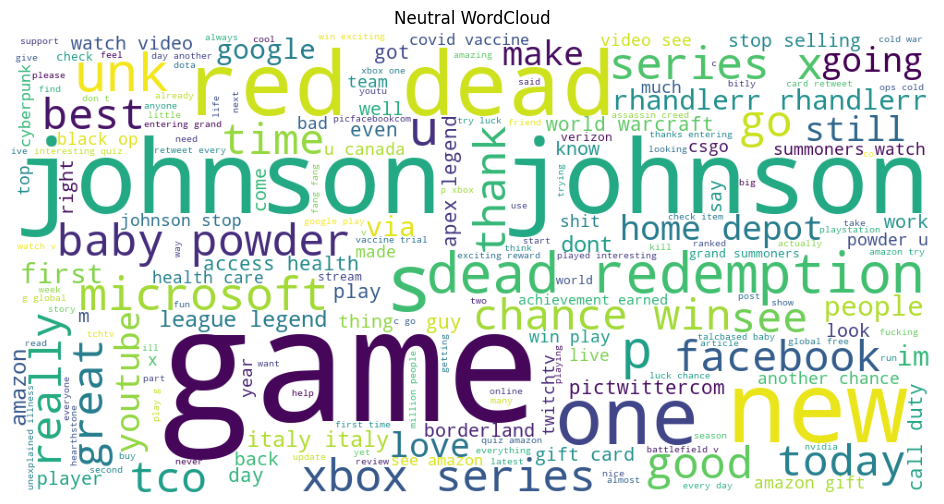

In [32]:
neutral = " ".join(df[df["Sentiment"]=="Neutral"]["Clean_Tweet"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(neutral)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Neutral WordCloud")
plt.show()

In [33]:
results = pd.DataFrame({
    "Tweet": df.loc[y_test.index, "Tweet"],
    "Actual": y_test,
    "Predicted": lr_predictions
})

misclassified = results[
    results["Actual"] != results["Predicted"]
]

misclassified.head(5)

,Tweet,Actual,Predicted
73803,Nvidia’s next Tesla GPUs could be 75% flat – g...,Neutral,Positive
9030,is,Negative,Neutral
6886,at,Negative,Neutral
14198,Dad Maxwell,Negative,Positive
59381,Stupidity !,Negative,Neutral


In [34]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions)
    ]
})

comparison

,Model,Accuracy
0,Naive Bayes,0.716237
1,Logistic Regression,0.757137


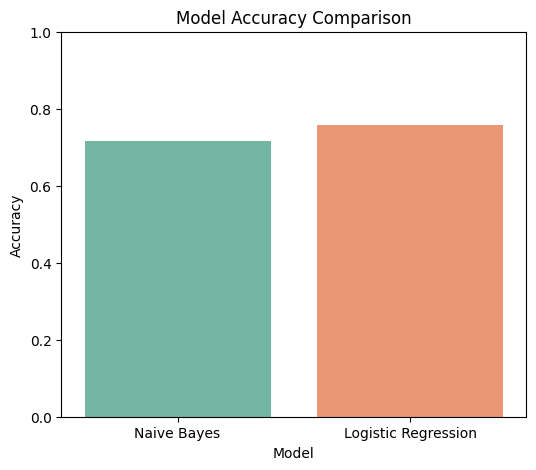

In [35]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")

plt.show()

In [36]:
df.to_csv("cleaned_sentiment_dataset.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
